# **Data Visualisation**


## Objectives

* To visualise sales trends and patterns in the cleaned Online Retail dataset.
* Analyse product performance customer behaviour and geographic sales.
* Create clear visualisations that can support business decision making.
* To develope interactive visualisations using Power BI.
## Inputs

* Cleaned Online Retail dataset:
'Online_Retail_Cleaned.csv'
* The dataset contains transaction, product, quantity, price, customer and country information.


## Outputs
* Sales trend visualisations.
* Product performance charts.
* Customer and geographic analysis.
* Key findings and business insights.
* Visualisation results to support the Power BI dashboard. 

## Additional Comments

The analysis uses the cleaned dataset produced during ETL stage.
Visualisations will be created using Python libraries such as pandas and matplotlib.
Interactive dashboard features will be developed using Power BI.



## Analytical Approach and Methodology

The project follows a structured data analysis process. The data was first collected from Kaggle Dataset. The ETL process was then used to clean and prepare the data by handling data quality issues and creating a sutiable cleaned dataset.

The clean dataset was then used for EDA to understand the main patterns and characteristics of the data. 
Discriptive statistics were used to understand sales, quantity and transaction values.

Data visualisation techniques were then applied to identify sales trends, product performance and customer behaviour. Line charts were used to analyse sales trends over time while other charts were used to compare products and customer segments.

These methodes were selected because they make the data easier to understand and help identify useful business insights for decision making.

---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [216]:
import os
current_dir = os.getcwd()
current_dir

'c:\\Users\\Pdhar\\OneDrive\\Documents'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [217]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [218]:
current_dir = os.getcwd()
current_dir

'c:\\Users\\Pdhar\\OneDrive'

# Section 1

---

## Data Loading

In [219]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Pdhar\OneDrive\Documents\GitHub\Online_Retail_Transaction_Analysis\Dataset\CleanData\Online_Retail_Cleaned.csv")
df.head()

C:\Users\Pdhar\AppData\Local\Temp\ipykernel_27416\2683411635.py:3: DtypeWarning:

Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.



,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


## Data Overview

The cleaned dataset is loaded for visualisation.
The dataset contains transaction information including quantity, unit price, total amount, customer details and country.

In [97]:
df.shape

(524878, 9)

In [98]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 524878 entries, 0 to 524877
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    524878 non-null  object 
 1   StockCode    524878 non-null  object 
 2   Description  524878 non-null  object 
 3   Quantity     524878 non-null  int64  
 4   InvoiceDate  524878 non-null  object 
 5   UnitPrice    524878 non-null  float64
 6   CustomerID   524878 non-null  int64  
 7   Country      524878 non-null  object 
 8   TotalAmount  524878 non-null  float64
dtypes: float64(2), int64(2), object(5)
memory usage: 36.0+ MB


## Discriptive Statistics
 Discriptive statistics are used to summarise the main numerical variables in the cleaned dataset. This helps to understand the typical values, variation and range of transactions.

In [99]:
df[['Quantity', 'UnitPrice', 'TotalAmount']].describe()

,Quantity,UnitPrice,TotalAmount
count,524878.000000,524878.000000,524878.000000
mean,10.616600,3.922573,20.275399
std,156.280031,36.093028,271.693566
min,1.000000,0.001000,0.001000
25%,1.000000,1.250000,3.900000
50%,4.000000,2.080000,9.920000
75%,11.000000,4.130000,17.700000
max,80995.000000,13541.330000,168469.600000


## Observation 
The quantity variable has a mean of around 10.62, median is 4,that shows most transaction have relatively small quantities. 

Unit price has a mean of around 3.92 and median of 2.08. It shows that most product have relatively low unit prices.

TotalAmount has a mean of around 20.27 and medianof 9.92. This show that most transactions have relatively low total amounts with some transactions having higher values. 

In [100]:
# Descriptive business statistics.
total_sales = df['TotalAmount'].sum()

number_of_transactions = df['InvoiceNo'].nunique()

average_transaction_value = total_sales / number_of_transactions

total_quantity = df['Quantity'].sum()

unique_customers = df['CustomerID'].nunique()

print("Total Sales: ", total_sales)
print("Average Transaction Value: ", average_transaction_value)
print("Total Quantity Sold: ", total_quantity)
print("Number of transactions: ", number_of_transactions)
print("Number of unique customers: ", unique_customers)

Total Sales:  10642110.803999998
Average Transaction Value:  533.1184652840395
Total Quantity Sold:  5572420
Number of transactions:  19962
Number of unique customers:  4338


### Observation
The dataset shows that total sales of approximately 10.64 million across 19,962 transactions. The average transaction value is probably 533.12. A total of 5,572,420 items were sold with 4,338 unique customers. These numbers provide an overview of the overall sales performance and customer activity.

## Trend Analysis
 This analysis examines how sales change over the time. A line chart is used to identify increases, decreases and patterns in sales across different time.

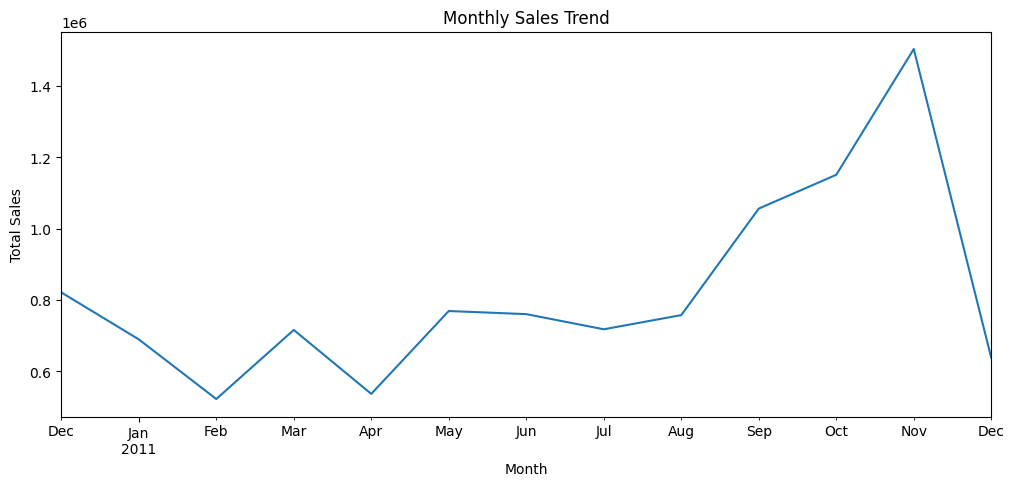

In [101]:
import matplotlib.pyplot as plt
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'],format='mixed', dayfirst=True)

monthly_sales = df.groupby(df['InvoiceDate'].dt.to_period('M'))['TotalAmount'].sum()

monthly_sales.index = monthly_sales.index.to_timestamp()

monthly_sales.plot(kind='line', figsize=(12, 5), title='Monthly Sales Trend', xlabel='Month', ylabel='Total Sales')

plt.show()

### Observation

The monthly sales trend shows that sales decreased from December to February.
Sales then increase in March follow by a small decrease in April.
From May onwards sales generally increased with the highest sales in November.
Overall, the chart shows an upward sales trend towards the end of the year. 


## Customer Segmentation

Customer segmentation groups customer based on their purchasing behaviour.

In this analysis, customers are grouped using their transaction frequency, total spending and total quantity purchased. 


In [102]:
customer_summary = df.groupby('CustomerID').agg(
    Number_of_Transactions=('InvoiceNo',
                            'nunique'),
    Total_Quantity=('Quantity', 
                    'sum'),
    Total_Spending=('TotalAmount', 
                    'sum')
                    ).reset_index()
customer_summary.head()

,CustomerID,Number_of_Transactions,Total_Quantity,Total_Spending
0,12346,1,74215,77183.60
1,12347,7,2458,4310.00
2,12348,4,2341,1797.24
3,12349,1,631,1757.55
4,12350,1,197,334.40


In [103]:
customer_summary['Customer_Segment'] = pd.cut(customer_summary['Total_Spending'],
                                             bins=[-1, 500, 2000, float('inf')],
                                             labels=['Low Spending', 'Medium Spending', 'High Spending'])
customer_summary['Customer_Segment'].value_counts()

Customer_Segment
Low Spending       1764
Medium Spending    1677
High Spending       897
Name: count, dtype: int64

### Customer Segmentation Observation

The customers are divided into three groups based on their total spending:
Low spending, medium spending and high spending. It help us to identify defferent customer groups and understand their purchasing behaviour. The results can be used to support targeted marketing and sales strategies.

## Product Analysis

Product Analysis is used to identify the most popular product in the dataset.

The top products are identified based on the total quantity sold. Bar and pie charts are used to visualise the most popular products and compare their contribution to total quantity sold.

In [104]:
product_quantity = df.groupby('Description')['Quantity']

In [105]:
product_quantity = product_quantity.sum()

In [106]:
top_products = product_quantity.sort_values(ascending=False).head(5)

top_products

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        78033
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54951
JUMBO BAG RED RETROSPOT               48371
WHITE HANGING HEART T-LIGHT HOLDER    37872
Name: Quantity, dtype: int64

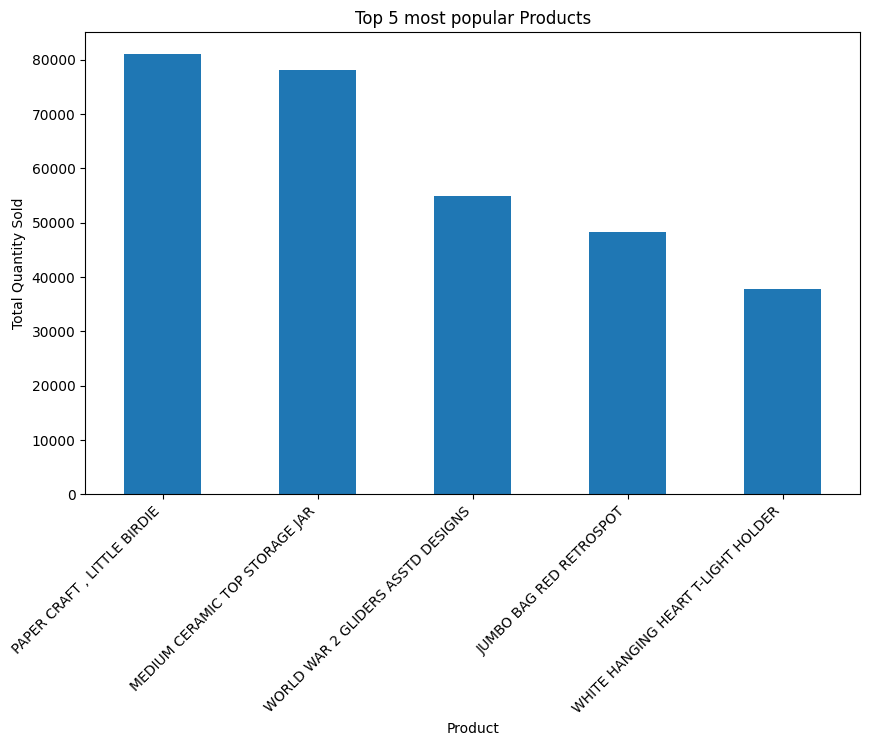

In [107]:
top_products.plot(kind='bar', figsize=(10,6), title='Top 5 most popular Products', 
                   xlabel='Product', ylabel='Total Quantity Sold')

plt.xticks(rotation=45, ha='right')
plt.show()

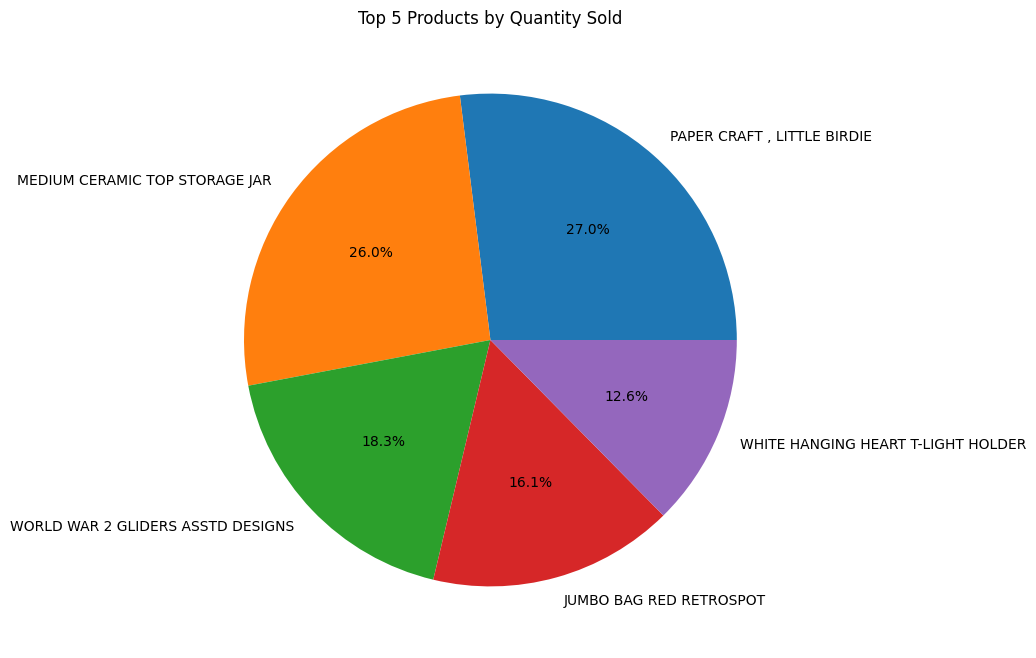

In [108]:
top_products.plot(
    kind='pie', figsize=(8, 8), autopct='%1.1f%%', 
    title='Top 5 Products by Quantity Sold')
plt.ylabel('') 
plt.show() 

### Product analysis Observation

The charts shows the five products with the highest total quantity sold.

The bar chart allows comparison of the quantity sold for each product, while the pie chart shows the proportion of total quantity represented by the top five products.

This analysis helps identify the moat popular products and supports decision about product availability and sales strategies.

## Geographic Analysis

Geographic analysis is used to understand sales across different customer countries. 

The total sales for each country are calculated and visualised using a bar chart.
This helps identify the countries that contribute most to sales and highlights important markets.

In [109]:
country_sales = df.groupby('Country')['TotalAmount'].sum().sort_values(ascending=False)

country_sales.head(10)

Country
United Kingdom    9001744.094
Netherlands        285446.340
EIRE               283140.520
Germany            228678.400
France             209625.370
Australia          138453.810
Spain               61558.560
Switzerland         57067.600
Belgium             41196.340
Sweden              38367.830
Name: TotalAmount, dtype: float64

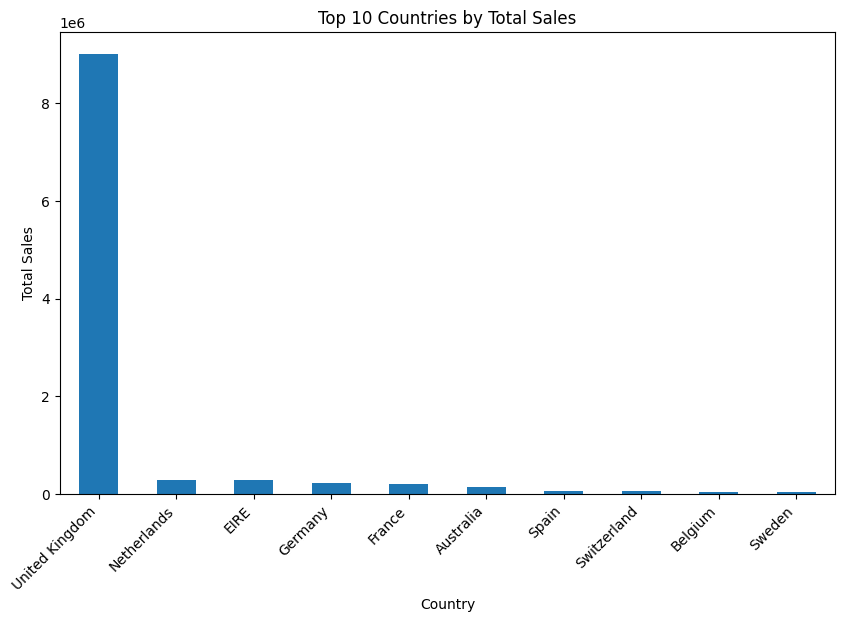

In [110]:
top_countries = country_sales.head(10)

top_countries.plot(kind='bar', figsize=(10,6), title='Top 10 Countries by Total Sales',
                   xlabel='Country', ylabel='Total Sales')
plt.xticks(rotation=45, ha='right')
plt.show()

### Geographic Analysis Observation

The bar chart shows the countries with the highest total sales. The results help identify the main markets and show where the business has the strongest sales performance. These findings can support decisions about marketing and sales strategies in different countries. 

# Section 2

# Visualisation Features

Interactive visualisation features will be used to help users explore the sales data.
Filter and interactive charts can help users compare sales by time, product, customer group and country.

## Interactive Filters

Interactive Filters allows users to explore the sales data by date, product, customer segment and country.
The fiters help users focus on specific parts of the dataset and compare sales performance.
These interactive features can also be implemented in the final Power BI dashboard.


In [111]:
%pip install ipywidgets

Note: you may need to restart the kernel to use updated packages.


In [112]:
import ipywidgets as widgets
country = widgets.Dropdown(
    options = ['All'] + 
sorted(df['Country'].dropna().unique
       ()),
    description = 'Country:'
)

product = widgets.Dropdown(
    options=['All'] + 
    sorted(df['Description'].dropna().unique()),
    description = 'Product:'
    )
display(country, product)

Dropdown(description='Country:', options=('All', 'Australia', 'Austria', 'Bahrain', 'Belgium', 'Brazil', 'Cana…

Dropdown(description='Product:', options=('All', ' 4 PURPLE FLOCK DINNER CANDLES', " 50'S CHRISTMAS GIFT BAG L…

---

In [113]:
print("Country Options: ", len(country.options))
print("Product Options: ", len(product.options))

Country Options:  39
Product Options:  4027


### Observation
The interactive filters allow users to explore sales data by country and product. Users can select different
options from the dropdown menus to focus on specific parts of the dataset. These filter suppprt interactive data exploration and can be extended to include data range and customer segment filters in the final Power BI dashboard.



## Dynamic charts and graphs
Dynamic charts allows users to explore the data interactively. The chart below update  the monthly sales  trends when a country or product is selected. This helps users to compare sales performance and identify changes in sales over the time.

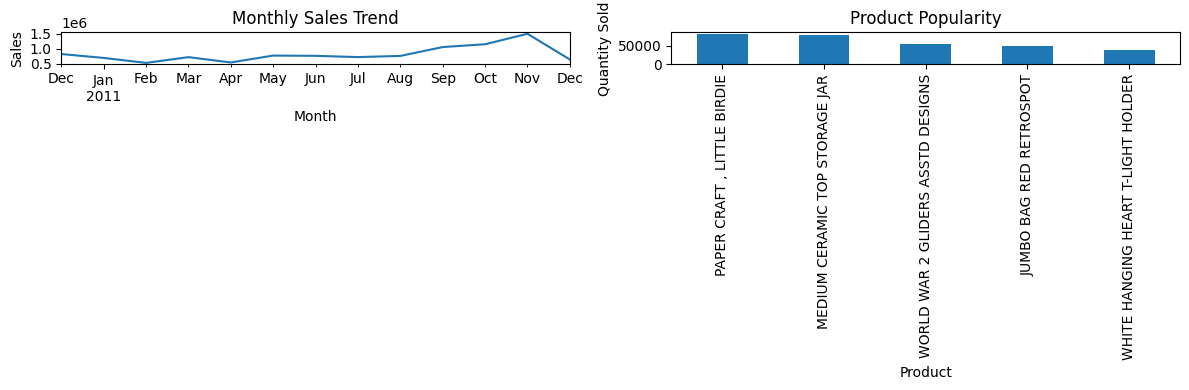

In [294]:
import matplotlib.pyplot as plt
import ipywidgets as widgets


def dynamic_chart(country):
    data = df.copy() 
    if country != 'All':
        data = data[data['Country'] == country]
    
        data['InvoiceDate']=pd.to_datetime(data['InvoiceDate'],
                                           format='mixed',
                                           errors='coerce')
        
        data = data.dropna(subset=['InvoiceDate'])

        sales = data.groupby(data['InvoiceDate'].dt.to_period('M')
)['TotalAmount'].sum()

        products = data.groupby('Description')['Quantity'].sum().nlargest(5)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sales.plot(kind='line')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Sales')

plt.subplot(1, 2, 2)
products.plot(kind='bar')
plt.title('Product Popularity')
plt.xlabel('Product')
plt.ylabel('Quantity Sold')

plt.tight_layout()
plt.show()

    

    

In [295]:
widgets.interact(
        dynamic_chart,
        country=['All'] +
sorted(df['Country'].dropna().unique())
    )

interactive(children=(Dropdown(description='country', options=('All', 'Australia', 'Austria', 'Bahrain', 'Belg…

<function __main__.dynamic_chart(country)>

### Dynamic Charts and Graphs Result

The dynamic charts shows monthly sales trends and the most popular products. The country filter allows users to view the results for different countries. This helps the business understand sales performance and product demand.

## Customer Insights 

Customers are divided into three part: low, medium and high value segments based on their total spending. Key metrics are calculated to compare the different customer groups.

In [119]:
sales = df.groupby(
    df['InvoiceDate'].dt.to_period('M')
    )['TotalAmount'].sum()

sales


InvoiceDate
2010-12     821452.730
2011-01     689811.610
2011-02     522545.560
2011-03     716215.260
2011-04     536968.491
2011-05     769296.610
2011-06     760547.010
2011-07     718076.121
2011-08     757841.380
2011-09    1056435.192
2011-10    1151263.730
2011-11    1503866.780
2011-12     637790.330
Freq: M, Name: TotalAmount, dtype: float64

In [253]:
# Create customer-level metrics
customer_metrics = (
    df.dropna(subset=['CustomerID'])
      .groupby('CustomerID')
      .agg(
          Total_Spend=('TotalAmount', 'sum'),
          Number_of_Purchases=('InvoiceNo', 'nunique'),
          Total_Quantity=('Quantity', 'sum')
      )
      .reset_index()
)

# Create three customer segments based on total spend
customer_metrics['Segment'] = pd.qcut(
    customer_metrics['Total_Spend'],
    q=3,
    labels=['Low', 'Medium', 'High']
)

# Summarise the customer segments
segment_summary = customer_metrics.groupby(
    'Segment', observed=True
).agg(
    Number_of_Customers=('Total_Spend', 'count'),
    Total_Spend=('Total_Spend', 'sum'),
    Average_Spend=('Total_Spend', 'mean'),
    Average_Purchases=('Number_of_Purchases', 'mean'),
    Total_Quantity=('Total_Quantity', 'sum')
)

segment_summary

,Number_of_Customers,Total_Spend,Average_Spend,Average_Purchases,Total_Quantity
Segment,,,,,
Low,1446,317006.670,219.230062,1.323651,204764
Medium,1446,1025187.923,708.981966,2.581604,623860
High,1446,9299916.211,6431.477324,9.899723,4743796


### Customer Insights Result
This analysis divides customer into three groups according to their total spending time: low, medium and high value customers.

Each segment contains 1,446 customers. The average spending increases substantially from the low to medium then high segment.

The high value customer segment has highest average spending, otherside low value segment has the lowest average spending. The medium value segment is between the two.

This result help the business understand customer value and compare that which customer groups contribute more to the total spending.


# Storytelling

This analysis provides an overview of sales performence, product popularity and customer behaviour.

The dynamic charts show how monthly sales changes from month to month, some months showing higher sales than others. This helps the business identify time of stronge and weak sales performance.

The product chart shows the popular product with the highest quantities sold. These products can be considered important products for the business because they have strong customer demand.

The customer insights analysis divides customer into three groups: low, medium and high value. Each group contains 1,446 customers. The high value customer group has the highest average spending, otherside the low value group has the lowest average spending. The medium value group has the lowest average spending. The medium value group is between the two.

Inshort, the analysis shows that customer spending and product dimand are most important factors in understanding business performance. These finding can help the business identify valuable customer, understand popular products, and make better decisions about sales and marketing.

---

## Conclusion

The analysis shows the main sales trends, popular products and different customer groups. High value customer have the highest average spending, otherhand low value customers have the lowest. These findings help the business understand, customers and sales performance.

## Next Steps

The business can focus on high value customer, promote popular products, monitor sales trends and create targeted marketing for different customer groups. In the future , machine learning could also be used to predict customer behaviour and future sales.

# Push files to Repo

* In cases where you don't need to push files to Repo, you may replace this section with "Conclusions and Next Steps" and state your conclusions and next steps.

In [ ]:
import os
try:
  # create your folder here
  # os.makedirs(name='')
except Exception as e:
  print(e)


IndentationError: expected an indented block after 'try' statement on line 2 (553063055.py, line 5)